# Project FORESIGHT

## Notebook 6 — Forecast Analysis & Business Recommendations

### Business Context

Notebook 5 developed and validated machine learning models for retail demand forecasting.

This notebook converts the model predictions into business-ready insights.

The analysis focuses on:

- Forecast accuracy
- Store-level demand
- SKU-level demand
- High-demand products
- Low-demand products
- Inventory risk
- Stockout risk
- Forecast error
- Demand concentration
- Business recommendations

The objective is to connect machine learning predictions with practical retail planning decisions.

### Objectives

This notebook will:

- Load the model predictions generated in Notebook 5
- Validate the prediction output
- Analyze forecast accuracy
- Identify high-demand products
- Identify low-demand products
- Analyze store-level demand
- Analyze SKU-level demand
- Identify potential stockout risks
- Estimate inventory requirements
- Create business recommendation tables
- Export business-ready datasets

In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/shadabkazi18
/kaggle/input/datasets/shadabkazi18/notebook-6-dataset
    model_results.csv
    forecast_predictions.csv
/kaggle/input/datasets/mrayyanshehzad
/kaggle/input/datasets/mrayyanshehzad/synthetic-retail-dataset-10-million-transactions
    README.md
/kaggle/input/datasets/mrayyanshehzad/synthetic-retail-dataset-10-million-transactions/retail_contaminated_dataset
    promotions.csv
    store_master.csv
    customer_master.csv
    sku_inventory_flags.csv
    inventory_snapshot.csv
    sales_transactions.csv
    sku_master.csv
/kaggle/input/datasets/mrayyanshehzad/synthetic-retail-dataset-10-million-transactions/retail_clean_dataset
    promotions.csv
    store_master.csv
    customer_master.csv
    sku_inventory_flags.csv
    inventory_snapshot.csv
    sales_transactions.csv
    sku_master.csv


In [3]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/shadabkazi18
/kaggle/input/datasets/shadabkazi18/notebook-6-dataset
    model_results.csv
    forecast_predictions.csv
/kaggle/input/datasets/mrayyanshehzad
/kaggle/input/datasets/mrayyanshehzad/synthetic-retail-dataset-10-million-transactions
    README.md
/kaggle/input/datasets/mrayyanshehzad/synthetic-retail-dataset-10-million-transactions/retail_contaminated_dataset
    promotions.csv
    store_master.csv
    customer_master.csv
    sku_inventory_flags.csv
    inventory_snapshot.csv
    sales_transactions.csv
    sku_master.csv
/kaggle/input/datasets/mrayyanshehzad/synthetic-retail-dataset-10-million-transactions/retail_clean_dataset
    promotions.csv
    store_master.csv
    customer_master.csv
    sku_inventory_flags.csv
    inventory_snapshot.csv
    sales_transactions.csv
    sku_master.csv


# 2. Load Forecast Predictions

The prediction dataset generated in Notebook 5 is loaded for business analysis.

The dataset contains actual demand, predicted demand, store information, SKU information, inventory features, pricing features, and other forecasting variables.

In [4]:
# ===========================================
# Load Forecast Predictions
# ===========================================

forecast_results = pd.read_csv(
    "/kaggle/input/datasets/shadabkazi18/notebook-6-dataset/forecast_predictions.csv"
)

model_results = pd.read_csv(
    "/kaggle/input/datasets/shadabkazi18/notebook-6-dataset/model_results.csv"
)

print("Forecast predictions loaded successfully!")
print("Forecast shape:", forecast_results.shape)
print("Model results shape:", model_results.shape)

Forecast predictions loaded successfully!
Forecast shape: (174727, 28)
Model results shape: (3, 4)


# 3. Validate Forecast Output

Before performing business analysis, the prediction dataset is checked for:

- Shape
- Columns
- Missing values
- Duplicate records
- Date range

In [5]:
# ===========================================
# Validate Forecast Output
# ===========================================

print("Forecast Predictions Shape:")
print(forecast_results.shape)

print("\nForecast Prediction Columns:")
print(forecast_results.columns.tolist())

print("\nFirst 5 Rows:")
display(forecast_results.head())

Forecast Predictions Shape:
(174727, 28)

Forecast Prediction Columns:
['date', 'store_id', 'sku_id', 'daily_quantity', 'daily_revenue', 'avg_price', 'avg_discount', 'transactions', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'rolling_std_30', 'last_restock_date', 'stock_on_hand', 'reorder_point', 'stock_cover', 'low_stock_flag', 'price_per_unit', 'discount_rate', 'price_change', 'price_change_pct', 'promotion_flag', 'discount_category', 'predicted_quantity']

First 5 Rows:


,date,store_id,sku_id,daily_quantity,daily_revenue,avg_price,avg_discount,transactions,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,last_restock_date,stock_on_hand,reorder_point,stock_cover,low_stock_flag,price_per_unit,discount_rate,price_change,price_change_pct,promotion_flag,discount_category,predicted_quantity
0,2025-07-02,ST24,SKU04710,1,1632.84,1632.84,0.0,1,1.0,1.0,1.0,1.0,1.428571,0.786796,1.366667,0.668675,2025-09-29,0.0,82.0,0.0,1,1632.84,0.0,0.0,0.0,0,No Discount,1.884329
1,2025-07-02,ST24,SKU04913,6,2801.46,466.91,0.0,2,4.0,3.0,2.0,2.0,2.857143,1.069045,2.166667,1.205829,2025-09-07,0.0,81.0,0.0,1,466.91,0.0,0.0,0.0,0,No Discount,3.739152
2,2025-07-02,ST25,SKU00002,3,211.14,70.38,0.0,2,1.0,4.0,3.0,2.0,2.571429,2.070197,2.433333,1.454679,2025-10-11,0.0,100.0,0.0,1,70.38,0.0,0.0,0.0,0,No Discount,3.766144
3,2025-07-02,ST25,SKU00079,2,395.80,197.90,0.0,1,1.0,2.0,4.0,4.0,2.857143,2.672612,2.566667,1.887953,2025-09-05,0.0,80.0,0.0,1,197.90,0.0,0.0,0.0,0,No Discount,1.913521
4,2025-07-02,ST25,SKU00169,2,190.74,95.37,0.0,1,2.0,2.0,4.0,2.0,2.000000,1.154701,2.133333,1.332183,2025-08-25,0.0,54.0,0.0,1,95.37,0.0,0.0,0.0,0,No Discount,1.878025


In [6]:
# ===========================================
# Check Prediction Columns
# ===========================================

required_columns = [
    "date",
    "store_id",
    "sku_id",
    "daily_quantity",
    "predicted_quantity"
]

print("Required Columns Check:")

for column in required_columns:
    print(f"{column}: {column in forecast_results.columns}")

Required Columns Check:
date: True
store_id: True
sku_id: True
daily_quantity: True
predicted_quantity: True


In [7]:
# ===========================================
# Prediction Quality Check
# ===========================================

print("Missing values:")
print(
    forecast_results[
        ["daily_quantity", "predicted_quantity"]
    ].isnull().sum()
)

print("\nPrediction summary:")
display(
    forecast_results[
        ["daily_quantity", "predicted_quantity"]
    ].describe()
)

Missing values:
daily_quantity        0
predicted_quantity    0
dtype: int64

Prediction summary:


,daily_quantity,predicted_quantity
count,174727.000000,174727.000000
mean,2.630326,2.631090
std,3.430080,3.153917
min,1.000000,1.411694
25%,1.000000,1.871963
50%,2.000000,1.883882
75%,3.000000,1.912036
max,86.000000,73.336730


# 4. Forecast Performance Summary

## Business Question

How closely does the forecasting model estimate actual demand?

The objective is to compare actual demand with predicted demand and identify overall forecast accuracy and potential areas of under- or over-forecasting.

In [8]:
# ===========================================
# Forecast Performance Summary
# ===========================================

actual = forecast_results["daily_quantity"]
predicted = forecast_results["predicted_quantity"]

mae = (actual - predicted).abs().mean()
rmse = ((actual - predicted) ** 2).mean() ** 0.5

print("Forecast Performance Summary")
print("=" * 40)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

Forecast Performance Summary
MAE  : 0.9989
RMSE : 1.3105


In [9]:
# ===========================================
# Actual vs Predicted Demand
# ===========================================

comparison = pd.DataFrame({
    "Actual Demand": actual,
    "Predicted Demand": predicted
})

display(comparison.head(10))

,Actual Demand,Predicted Demand
0,1,1.884329
1,6,3.739152
2,3,3.766144
3,2,1.913521
4,2,1.878025
5,6,3.742833
6,3,3.754621
7,1,1.841223
8,1,1.878896
9,1,1.865652


In [10]:
# ===========================================
# Aggregate Demand Comparison
# ===========================================

total_actual = actual.sum()
total_predicted = predicted.sum()

difference = total_predicted - total_actual
difference_pct = (difference / total_actual) * 100

print("Aggregate Demand Comparison")
print("=" * 40)

print(f"Total Actual Demand    : {total_actual:,.0f}")
print(f"Total Predicted Demand : {total_predicted:,.0f}")
print(f"Difference             : {difference:,.0f}")
print(f"Difference %           : {difference_pct:.2f}%")

Aggregate Demand Comparison
Total Actual Demand    : 459,589
Total Predicted Demand : 459,722
Difference             : 133
Difference %           : 0.03%


# 5. Store-Level Forecast Analysis

## Business Question

Which stores have the largest differences between actual and predicted demand?

Store-level analysis helps identify locations where the forecasting model may consistently overestimate or underestimate demand.

In [11]:
# ===========================================
# Store-Level Forecast Analysis
# ===========================================

store_summary = (
    forecast_results
    .groupby("store_id")
    .agg(
        actual_demand=("daily_quantity", "sum"),
        predicted_demand=("predicted_quantity", "sum")
    )
    .reset_index()
)

store_summary["difference"] = (
    store_summary["predicted_demand"]
    - store_summary["actual_demand"]
)

store_summary["difference_pct"] = (
    store_summary["difference"]
    / store_summary["actual_demand"]
    * 100
)

store_summary.head()

,store_id,actual_demand,predicted_demand,difference,difference_pct
0,ST01,8652,8626.005260,-25.994740,-0.300448
1,ST02,5356,5406.467510,50.467510,0.942261
2,ST03,19194,19213.267363,19.267363,0.100382
3,ST04,19160,19225.118670,65.118670,0.339868
4,ST05,12659,12817.858668,158.858668,1.254907


In [12]:
# ===========================================
# Largest Forecast Differences
# ===========================================

print("Most Under-Forecasted Stores")
print("=" * 40)

display(
    store_summary
    .sort_values("difference")
    .head(10)
)

print("\nMost Over-Forecasted Stores")
print("=" * 40)

display(
    store_summary
    .sort_values("difference", ascending=False)
    .head(10)
)

Most Under-Forecasted Stores


,store_id,actual_demand,predicted_demand,difference,difference_pct
16,ST17,21756,21478.618527,-277.381473,-1.274965
7,ST08,14169,13920.766397,-248.233603,-1.751949
14,ST15,12109,11968.379686,-140.620314,-1.161288
21,ST22,21481,21365.513711,-115.486289,-0.537621
12,ST13,9516,9401.917867,-114.082133,-1.198845
27,ST28,17997,17893.740921,-103.259079,-0.573757
8,ST09,15233,15139.105410,-93.894590,-0.616389
10,ST11,20134,20046.382211,-87.617789,-0.435173
6,ST07,23724,23677.524519,-46.475481,-0.195901
22,ST23,7807,7778.014076,-28.985924,-0.371281



Most Over-Forecasted Stores


,store_id,actual_demand,predicted_demand,difference,difference_pct
19,ST20,27250,27480.402572,230.402572,0.845514
5,ST06,21423,21613.832558,190.832558,0.890784
4,ST05,12659,12817.858668,158.858668,1.254907
17,ST18,11351,11483.815103,132.815103,1.170074
20,ST21,27719,27845.287462,126.287462,0.455599
28,ST29,21173,21289.985039,116.985039,0.552520
26,ST27,15330,15444.356778,114.356778,0.745967
3,ST04,19160,19225.118670,65.118670,0.339868
24,ST25,11243,11302.111808,59.111808,0.525765
29,ST30,22926,22978.295109,52.295109,0.228104


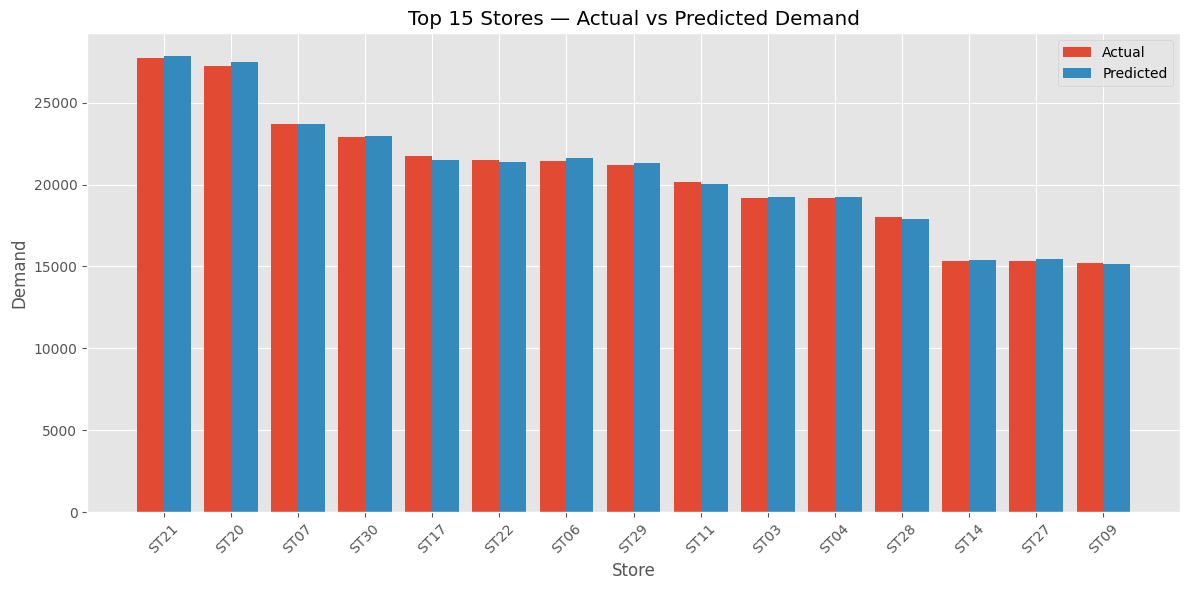

In [13]:
# ===========================================
# Actual vs Predicted Demand by Store
# ===========================================

import matplotlib.pyplot as plt

plot_data = store_summary.sort_values(
    "actual_demand",
    ascending=False
).head(15)

plt.figure(figsize=(12, 6))

x = range(len(plot_data))

plt.bar(
    [i - 0.2 for i in x],
    plot_data["actual_demand"],
    width=0.4,
    label="Actual"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_data["predicted_demand"],
    width=0.4,
    label="Predicted"
)

plt.xticks(
    x,
    plot_data["store_id"],
    rotation=45
)

plt.xlabel("Store")
plt.ylabel("Demand")
plt.title("Top 15 Stores — Actual vs Predicted Demand")
plt.legend()
plt.tight_layout()
plt.show()

# 6. SKU-Level Forecast Analysis

## Business Question

Which products have the largest differences between actual and predicted demand?

SKU-level analysis helps identify products where forecast accuracy may affect inventory planning, replenishment, and stock availability.

In [14]:
# ===========================================
# SKU-Level Forecast Analysis
# ===========================================

sku_summary = (
    forecast_results
    .groupby("sku_id")
    .agg(
        actual_demand=("daily_quantity", "sum"),
        predicted_demand=("predicted_quantity", "sum")
    )
    .reset_index()
)

sku_summary["difference"] = (
    sku_summary["predicted_demand"]
    - sku_summary["actual_demand"]
)

sku_summary["difference_pct"] = (
    sku_summary["difference"]
    / sku_summary["actual_demand"]
    * 100
)

sku_summary.head()

,sku_id,actual_demand,predicted_demand,difference,difference_pct
0,SKU00001,35,36.664815,1.664815,4.756615
1,SKU00002,2375,2377.814464,2.814464,0.118504
2,SKU00005,49,40.581038,-8.418962,-17.181554
3,SKU00006,27,34.953910,7.953910,29.458928
4,SKU00007,69,64.610798,-4.389202,-6.361163


In [15]:
# ===========================================
# Largest SKU Forecast Differences
# ===========================================

print("Most Under-Forecasted SKUs")
print("=" * 40)

display(
    sku_summary
    .sort_values("difference")
    .head(10)
)

print("\nMost Over-Forecasted SKUs")
print("=" * 40)

display(
    sku_summary
    .sort_values("difference", ascending=False)
    .head(10)
)

Most Under-Forecasted SKUs


,sku_id,actual_demand,predicted_demand,difference,difference_pct
3106,SKU04321,44069,43785.647959,-283.352041,-0.642974
2084,SKU02954,3430,3318.025471,-111.974529,-3.264564
3307,SKU04596,14735,14632.205338,-102.794662,-0.697622
177,SKU00264,3111,3009.603369,-101.396631,-3.259294
2007,SKU02858,4299,4214.914418,-84.085582,-1.955934
2636,SKU03702,1511,1432.868142,-78.131858,-5.170871
3112,SKU04329,2558,2495.561271,-62.438729,-2.440920
738,SKU01037,1743,1680.857084,-62.142916,-3.565285
287,SKU00416,1032,970.304798,-61.695202,-5.978217
2586,SKU03633,916,858.266817,-57.733183,-6.302749



Most Over-Forecasted SKUs


,sku_id,actual_demand,predicted_demand,difference,difference_pct
3289,SKU04571,6112,6210.765937,98.765937,1.615935
2991,SKU04166,2672,2749.428611,77.428611,2.897777
2733,SKU03840,2346,2418.724014,72.724014,3.099915
2157,SKU03057,1021,1079.930421,58.930421,5.771834
823,SKU01164,967,1025.046882,58.046882,6.002780
1852,SKU02640,985,1042.417477,57.417477,5.829185
709,SKU00996,1198,1254.742598,56.742598,4.736444
39,SKU00062,1365,1418.586535,53.586535,3.925753
190,SKU00286,2910,2962.719878,52.719878,1.811680
339,SKU00484,930,973.100145,43.100145,4.634424


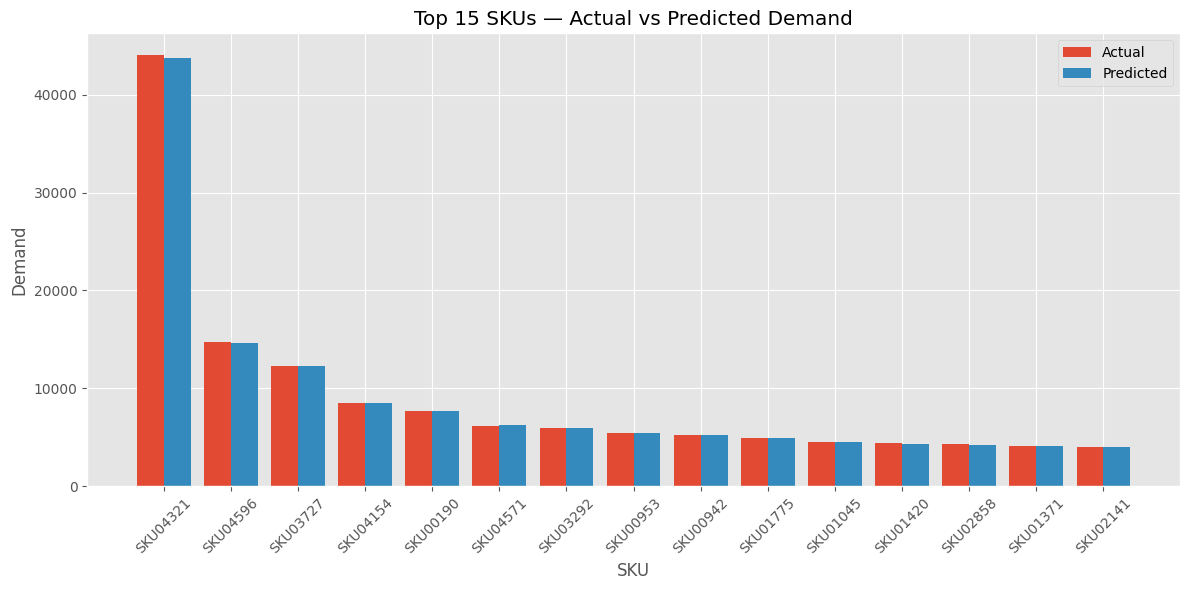

In [16]:
# ===========================================
# Actual vs Predicted Demand by SKU
# ===========================================

plot_data = (
    sku_summary
    .sort_values("actual_demand", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

x = range(len(plot_data))

plt.bar(
    [i - 0.2 for i in x],
    plot_data["actual_demand"],
    width=0.4,
    label="Actual"
)

plt.bar(
    [i + 0.2 for i in x],
    plot_data["predicted_demand"],
    width=0.4,
    label="Predicted"
)

plt.xticks(
    x,
    plot_data["sku_id"],
    rotation=45
)

plt.xlabel("SKU")
plt.ylabel("Demand")
plt.title("Top 15 SKUs — Actual vs Predicted Demand")
plt.legend()

plt.tight_layout()
plt.show()

# 7. Forecast Accuracy Analysis

## Business Question

Where is the forecasting model performing well, and where are forecast errors concentrated?

Forecast accuracy is evaluated using absolute error and percentage error at store and SKU levels.

In [17]:
# ===========================================
# Row-Level Forecast Error
# ===========================================

forecast_results["forecast_error"] = (
    forecast_results["predicted_quantity"]
    - forecast_results["daily_quantity"]
)

forecast_results["absolute_error"] = (
    forecast_results["forecast_error"].abs()
)

forecast_results["absolute_percentage_error"] = (
    forecast_results["absolute_error"]
    / forecast_results["daily_quantity"].replace(0, 1)
    * 100
)

display(
    forecast_results[
        [
            "date",
            "store_id",
            "sku_id",
            "daily_quantity",
            "predicted_quantity",
            "forecast_error",
            "absolute_error"
        ]
    ].head()
)

,date,store_id,sku_id,daily_quantity,predicted_quantity,forecast_error,absolute_error
0,2025-07-02,ST24,SKU04710,1,1.884329,0.884329,0.884329
1,2025-07-02,ST24,SKU04913,6,3.739152,-2.260848,2.260848
2,2025-07-02,ST25,SKU00002,3,3.766144,0.766144,0.766144
3,2025-07-02,ST25,SKU00079,2,1.913521,-0.086479,0.086479
4,2025-07-02,ST25,SKU00169,2,1.878025,-0.121975,0.121975


In [18]:
# ===========================================
# Store-Level Accuracy
# ===========================================

store_accuracy = (
    forecast_results
    .groupby("store_id")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("forecast_error", lambda x: (x ** 2).mean() ** 0.5),
        actual_demand=("daily_quantity", "sum"),
        predicted_demand=("predicted_quantity", "sum")
    )
    .reset_index()
)

store_accuracy["difference_pct"] = (
    (store_accuracy["predicted_demand"] -
     store_accuracy["actual_demand"])
    / store_accuracy["actual_demand"]
    * 100
)

display(
    store_accuracy.sort_values("MAE").head(10)
)

,store_id,MAE,RMSE,actual_demand,predicted_demand,difference_pct
1,ST02,0.921643,1.154727,5356,5406.467510,0.942261
18,ST19,0.935167,1.163877,8536,8547.998087,0.140559
22,ST23,0.941234,1.170535,7807,7778.014076,-0.371281
0,ST01,0.943104,1.185687,8652,8626.005260,-0.300448
17,ST18,0.943953,1.187585,11351,11483.815103,1.170074
4,ST05,0.944811,1.174869,12659,12817.858668,1.254907
25,ST26,0.949840,1.195091,7646,7623.285395,-0.297078
9,ST10,0.970042,1.216533,8896,8921.386588,0.285371
15,ST16,0.973819,1.237913,9376,9389.182929,0.140603
23,ST24,0.973953,1.227725,10501,10532.887649,0.303663


In [19]:
# ===========================================
# SKU-Level Accuracy
# ===========================================

sku_accuracy = (
    forecast_results
    .groupby("sku_id")
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("forecast_error", lambda x: (x ** 2).mean() ** 0.5),
        actual_demand=("daily_quantity", "sum"),
        predicted_demand=("predicted_quantity", "sum")
    )
    .reset_index()
)

sku_accuracy["difference_pct"] = (
    (sku_accuracy["predicted_demand"] -
     sku_accuracy["actual_demand"])
    / sku_accuracy["actual_demand"]
    * 100
)

display(
    sku_accuracy.sort_values("MAE").head(10)
)

,sku_id,MAE,RMSE,actual_demand,predicted_demand,difference_pct
3559,SKU04968,0.029651,0.029651,2,2.029651,1.482560
1464,SKU02096,0.064183,0.064183,2,1.935817,-3.209125
656,SKU00922,0.082329,0.082498,4,3.835342,-4.116443
1195,SKU01707,0.113647,0.113659,4,3.772705,-5.682365
894,SKU01268,0.116451,0.116451,2,1.883549,-5.822525
265,SKU00386,0.123216,0.123216,2,1.876784,-6.160800
344,SKU00491,0.123450,0.123501,4,3.753101,-6.172482
700,SKU00983,0.124165,0.124251,4,3.751669,-6.208275
871,SKU01234,0.128566,0.128589,4,3.742868,-6.428312
1656,SKU02365,0.132589,0.133215,6,5.602233,-6.629453


# 8. Time-Based Forecast Analysis

## Business Question

How closely does predicted demand follow actual demand over time?

Time-based analysis helps identify whether the model captures changes in demand across the forecasting period.

In [20]:
# ===========================================
# Daily Demand Trend
# ===========================================

daily_forecast = (
    forecast_results
    .groupby("date")
    .agg(
        actual_demand=("daily_quantity", "sum"),
        predicted_demand=("predicted_quantity", "sum")
    )
    .reset_index()
    .sort_values("date")
)

display(daily_forecast.head())

,date,actual_demand,predicted_demand
0,2025-07-02,527,501.558020
1,2025-07-03,2232,2233.766988
2,2025-07-04,2296,2282.847015
3,2025-07-05,2087,2122.467695
4,2025-07-06,2157,2157.791472


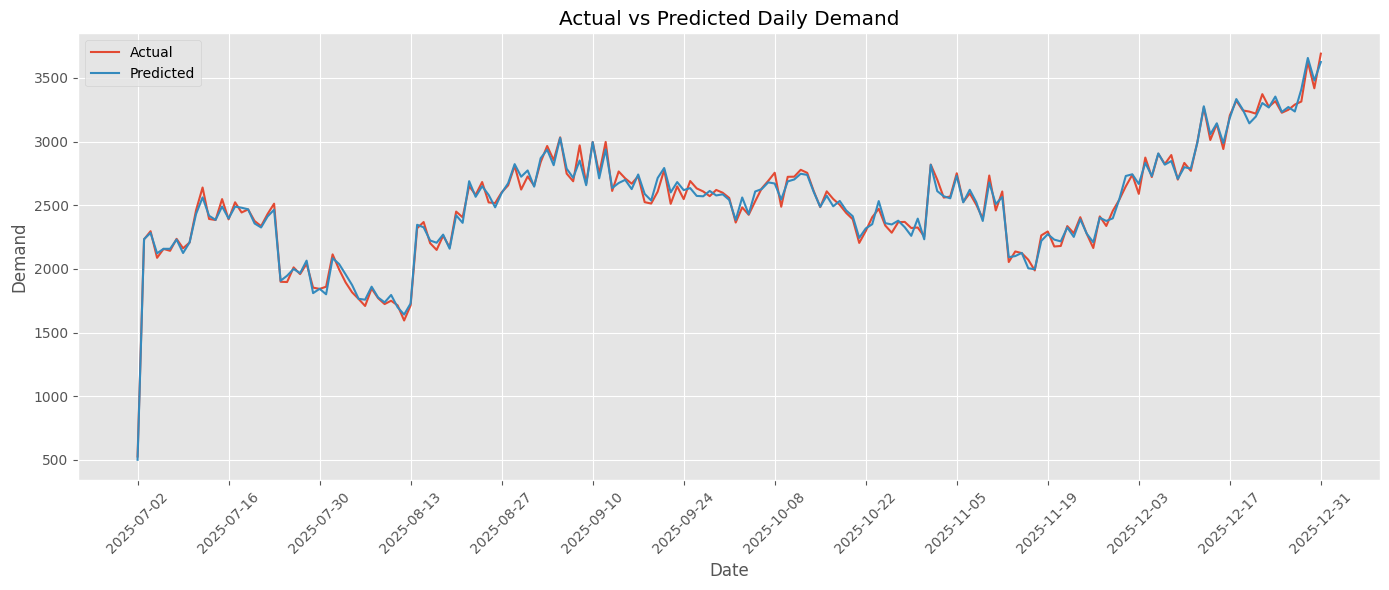

In [21]:
# ===========================================
# Actual vs Predicted Daily Demand
# ===========================================

plt.figure(figsize=(14, 6))

plt.plot(
    daily_forecast["date"],
    daily_forecast["actual_demand"],
    label="Actual",
    linewidth=1.5
)

plt.plot(
    daily_forecast["date"],
    daily_forecast["predicted_demand"],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Daily Demand")

plt.legend()

# Show fewer date labels
plt.xticks(
    daily_forecast["date"][::14],
    rotation=45
)

plt.tight_layout()
plt.show()

# 9. Forecast Error Trend

## Business Question

Does forecast error increase or decrease over time?

Monitoring forecast error over time can reveal periods where the model struggles to capture demand changes.

In [22]:
# ===========================================
# Daily Forecast Error
# ===========================================

daily_error = (
    forecast_results
    .groupby("date")
    .agg(
        MAE=("absolute_error", "mean"),
        actual_demand=("daily_quantity", "sum"),
        predicted_demand=("predicted_quantity", "sum")
    )
    .reset_index()
    .sort_values("date")
)

display(daily_error.head())

,date,MAE,actual_demand,predicted_demand
0,2025-07-02,1.083310,527,501.558020
1,2025-07-03,0.995491,2232,2233.766988
2,2025-07-04,0.974838,2296,2282.847015
3,2025-07-05,0.954166,2087,2122.467695
4,2025-07-06,0.956690,2157,2157.791472


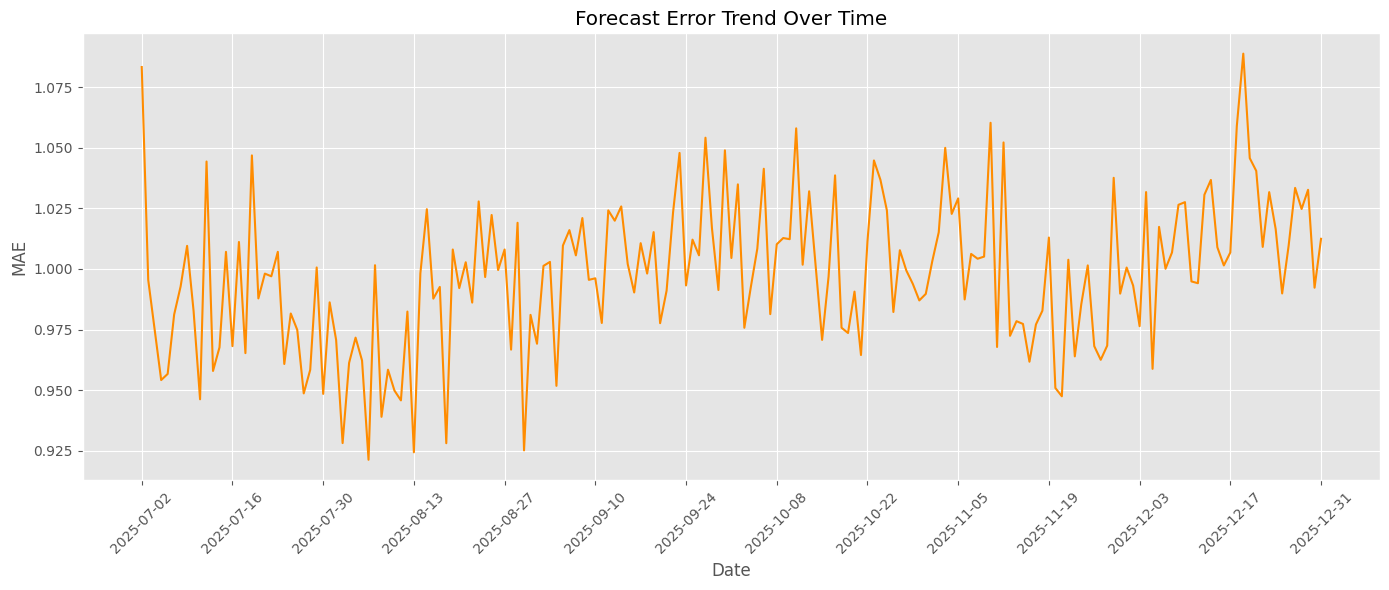

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_error["date"],
    daily_error["MAE"],
    color="darkorange",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Forecast Error Trend Over Time")

plt.xticks(
    daily_error["date"][::14],
    rotation=45
)

plt.tight_layout()
plt.show()

# 10. Inventory Risk Analysis

## Business Question

Which products and stores may face inventory pressure based on predicted demand and current stock?

Combining demand forecasts with inventory indicators can help identify potential replenishment risks.

In [24]:
# ===========================================
# Inventory Risk Summary
# ===========================================

inventory_analysis = forecast_results.copy()

inventory_analysis["forecast_demand_gap"] = (
    inventory_analysis["stock_on_hand"]
    - inventory_analysis["predicted_quantity"]
)

inventory_analysis["forecast_stock_risk"] = (
    inventory_analysis["stock_on_hand"]
    < inventory_analysis["predicted_quantity"]
)

display(
    inventory_analysis[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "stock_cover",
            "predicted_quantity",
            "forecast_demand_gap",
            "forecast_stock_risk"
        ]
    ].head(10)
)

,store_id,sku_id,stock_on_hand,reorder_point,stock_cover,predicted_quantity,forecast_demand_gap,forecast_stock_risk
0,ST24,SKU04710,0.0,82.0,0.0,1.884329,-1.884329,True
1,ST24,SKU04913,0.0,81.0,0.0,3.739152,-3.739152,True
2,ST25,SKU00002,0.0,100.0,0.0,3.766144,-3.766144,True
3,ST25,SKU00079,0.0,80.0,0.0,1.913521,-1.913521,True
4,ST25,SKU00169,0.0,54.0,0.0,1.878025,-1.878025,True
5,ST25,SKU00500,0.0,88.0,0.0,3.742833,-3.742833,True
6,ST25,SKU00953,0.0,38.0,0.0,3.754621,-3.754621,True
7,ST25,SKU01021,0.0,75.0,0.0,1.841223,-1.841223,True
8,ST25,SKU01418,13.0,39.0,7.0,1.878896,11.121104,False
9,ST25,SKU02176,0.0,36.0,0.0,1.865652,-1.865652,True


In [25]:
# ===========================================
# Potential Inventory Risk
# ===========================================

risk_summary = (
    inventory_analysis
    .groupby("store_id")
    .agg(
        total_records=("sku_id", "count"),
        risky_records=("forecast_stock_risk", "sum")
    )
    .reset_index()
)

risk_summary["risk_percentage"] = (
    risk_summary["risky_records"]
    / risk_summary["total_records"]
    * 100
)

display(
    risk_summary
    .sort_values("risk_percentage", ascending=False)
    .head(15)
)

,store_id,total_records,risky_records,risk_percentage
9,ST10,3936,3201,81.326220
12,ST13,3992,3238,81.112224
14,ST15,4141,3133,75.658054
18,ST19,3918,2939,75.012762
11,ST12,4228,3171,75.000000
0,ST01,3858,2880,74.650078
22,ST23,3701,2737,73.952986
24,ST25,3927,2872,73.134708
25,ST26,3503,2559,73.051670
23,ST24,4449,3243,72.892785


# 11. Low Stock Analysis

## Business Question

How much of the forecasted demand is associated with products already flagged as low stock?

This analysis connects the forecasting model with inventory replenishment decisions.

In [26]:
# ===========================================
# Low Stock Summary
# ===========================================

low_stock_summary = (
    forecast_results
    .groupby("low_stock_flag")
    .agg(
        records=("sku_id", "count"),
        actual_demand=("daily_quantity", "sum"),
        predicted_demand=("predicted_quantity", "sum")
    )
    .reset_index()
)

display(low_stock_summary)

,low_stock_flag,records,actual_demand,predicted_demand
0,0,43154,94702,95011.961808
1,1,131573,364887,364710.414036


In [27]:
# ===========================================
# Low Stock Predicted Demand
# ===========================================

low_stock_demand = forecast_results[
    forecast_results["low_stock_flag"] == 1
]

print("Low Stock Records:", len(low_stock_demand))

print(
    "Predicted Demand for Low Stock Records:",
    low_stock_demand["predicted_quantity"].sum()
)

print(
    "Actual Demand for Low Stock Records:",
    low_stock_demand["daily_quantity"].sum()
)

Low Stock Records: 131573
Predicted Demand for Low Stock Records: 364710.4140365
Actual Demand for Low Stock Records: 364887


# 12. Promotion and Demand Analysis

## Business Question

Does demand differ between promotional and non-promotional periods?

Understanding promotional demand patterns can help improve inventory planning and forecasting.

In [28]:
# ===========================================
# Promotion Demand Analysis
# ===========================================

promotion_summary = (
    forecast_results
    .groupby("promotion_flag")
    .agg(
        records=("sku_id", "count"),
        actual_demand=("daily_quantity", "mean"),
        predicted_demand=("predicted_quantity", "mean")
    )
    .reset_index()
)

display(promotion_summary)

,promotion_flag,records,actual_demand,predicted_demand
0,0,174727,2.630326,2.63109


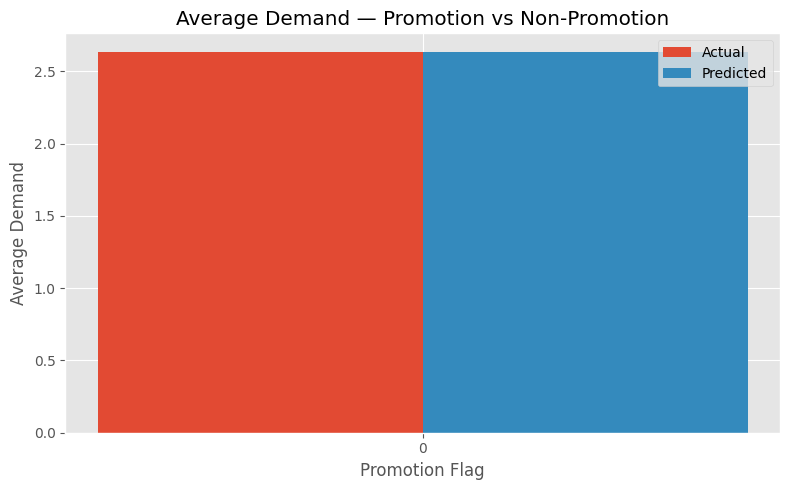

In [29]:
# ===========================================
# Promotion Demand Comparison
# ===========================================

plt.figure(figsize=(8, 5))

x = range(len(promotion_summary))

plt.bar(
    [i - 0.2 for i in x],
    promotion_summary["actual_demand"],
    width=0.4,
    label="Actual"
)

plt.bar(
    [i + 0.2 for i in x],
    promotion_summary["predicted_demand"],
    width=0.4,
    label="Predicted"
)

plt.xticks(
    x,
    promotion_summary["promotion_flag"]
)

plt.xlabel("Promotion Flag")
plt.ylabel("Average Demand")
plt.title("Average Demand — Promotion vs Non-Promotion")
plt.legend()

plt.tight_layout()
plt.show()

# 13. Discount and Demand Analysis

## Business Question

How does demand vary across different discount levels?

This analysis helps determine whether discounting is associated with changes in customer demand.

In [30]:
print("Discount Categories:")
print(forecast_results["discount_category"].value_counts(dropna=False))

Discount Categories:
discount_category
No Discount    174727
Name: count, dtype: int64


In [31]:
print("\nUnique Discount Categories:")
print(forecast_results["discount_category"].unique())


Unique Discount Categories:
['No Discount']


In [32]:
# ===========================================
# Discount Category Analysis
# ===========================================

discount_summary = (
    forecast_results
    .groupby("discount_category")
    .agg(
        records=("sku_id", "count"),
        actual_demand=("daily_quantity", "mean"),
        predicted_demand=("predicted_quantity", "mean"),
        avg_discount=("discount_rate", "mean")
    )
    .reset_index()
)

display(discount_summary)

,discount_category,records,actual_demand,predicted_demand,avg_discount
0,No Discount,174727,2.630326,2.63109,0.0


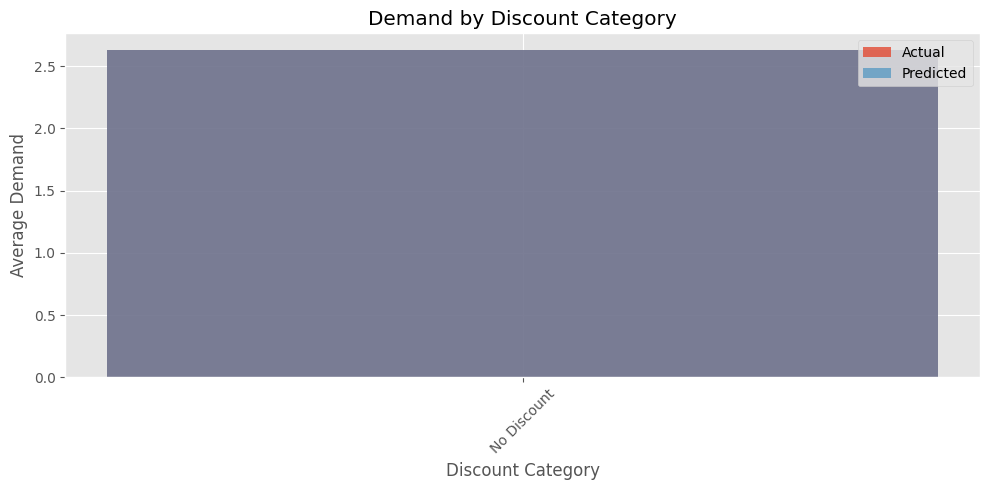

In [33]:
# ===========================================
# Discount vs Demand
# ===========================================

plt.figure(figsize=(10, 5))

plt.bar(
    discount_summary["discount_category"],
    discount_summary["actual_demand"],
    alpha=0.8,
    label="Actual"
)

plt.bar(
    discount_summary["discount_category"],
    discount_summary["predicted_demand"],
    alpha=0.6,
    label="Predicted"
)

plt.xlabel("Discount Category")
plt.ylabel("Average Demand")
plt.title("Demand by Discount Category")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 14. Price and Demand Analysis

## Business Question

How does demand behave across different price levels?

Price analysis provides additional business context for interpreting demand forecasts.

In [34]:
# ===========================================
# Price Statistics
# ===========================================

print("Price Statistics")
print("=" * 40)

print(
    forecast_results["price_per_unit"].describe()
)

Price Statistics
count    174727.000000
mean        585.180738
std         700.070511
min          24.410000
25%         170.160000
50%         283.280000
75%         681.440000
max        4755.470000
Name: price_per_unit, dtype: float64


In [35]:
# ===========================================
# Price vs Actual Demand
# ===========================================

price_analysis = (
    forecast_results[
        ["price_per_unit", "daily_quantity", "predicted_quantity"]
    ]
    .dropna()
)

display(price_analysis.head(10))

,price_per_unit,daily_quantity,predicted_quantity
0,1632.84,1,1.884329
1,466.91,6,3.739152
2,70.38,3,3.766144
3,197.90,2,1.913521
4,95.37,2,1.878025
5,1264.58,6,3.742833
6,273.99,3,3.754621
7,1243.47,1,1.841223
8,1090.09,1,1.878896
9,989.87,1,1.865652


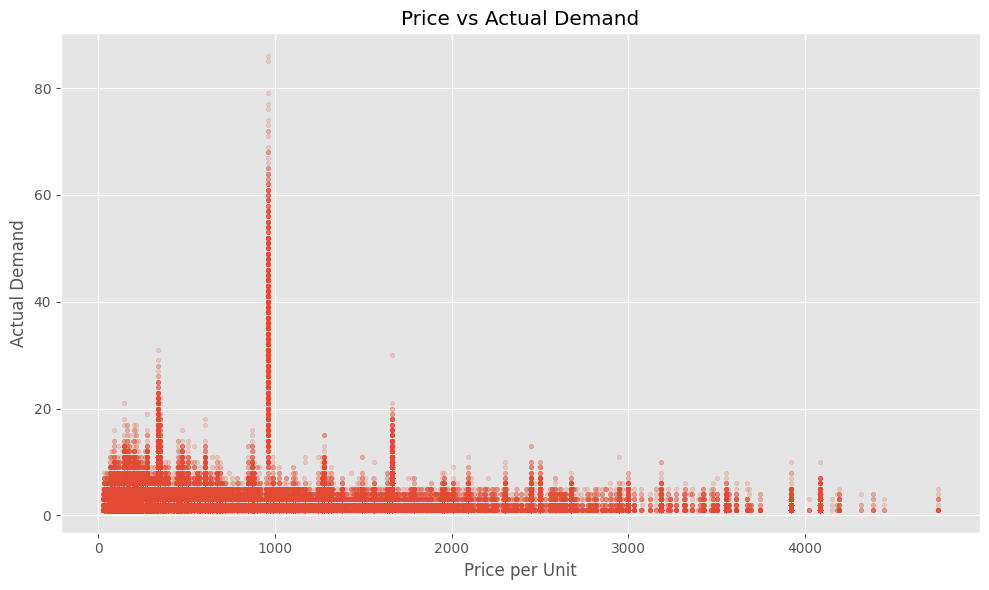

In [36]:
# ===========================================
# Price vs Demand Scatter Plot
# ===========================================

plt.figure(figsize=(10, 6))

plt.scatter(
    price_analysis["price_per_unit"],
    price_analysis["daily_quantity"],
    alpha=0.2,
    s=10
)

plt.xlabel("Price per Unit")
plt.ylabel("Actual Demand")
plt.title("Price vs Actual Demand")

plt.tight_layout()
plt.show()

# 15. Forecasting Business KPI Summary

## Business Question

What are the most important forecasting and inventory indicators for business decision-making?

This section summarizes model performance and demand insights into a compact KPI view.

In [37]:
# ===========================================
# Business KPI Summary
# ===========================================

total_actual = forecast_results["daily_quantity"].sum()
total_predicted = forecast_results["predicted_quantity"].sum()

mae = forecast_results["absolute_error"].mean()
rmse = (
    (forecast_results["forecast_error"] ** 2).mean()
    ** 0.5
)

forecast_difference = total_predicted - total_actual

forecast_difference_pct = (
    forecast_difference / total_actual * 100
)

low_stock_records = (
    forecast_results["low_stock_flag"] == 1
).sum()

promotion_records = (
    forecast_results["promotion_flag"] == 1
).sum()

print("=" * 55)
print("PROJECT FORESIGHT — BUSINESS KPI SUMMARY")
print("=" * 55)

print(f"Total Actual Demand       : {total_actual:,.0f}")
print(f"Total Predicted Demand    : {total_predicted:,.0f}")
print(f"Forecast Difference       : {forecast_difference:,.0f}")
print(f"Forecast Difference %     : {forecast_difference_pct:.2f}%")
print(f"MAE                       : {mae:.4f}")
print(f"RMSE                      : {rmse:.4f}")
print(f"Low Stock Records         : {low_stock_records:,}")
print(f"Promotion Records         : {promotion_records:,}")
print("=" * 55)

PROJECT FORESIGHT — BUSINESS KPI SUMMARY
Total Actual Demand       : 459,589
Total Predicted Demand    : 459,722
Forecast Difference       : 133
Forecast Difference %     : 0.03%
MAE                       : 0.9989
RMSE                      : 1.3105
Low Stock Records         : 131,573
Promotion Records         : 0


# 16. Key Business Insights

The forecasting analysis provides several business insights:

### 1. Demand Forecasting
The model provides predicted demand at store and SKU level, allowing businesses to move from reactive inventory decisions toward forecast-driven planning.

### 2. Inventory Planning
Predicted demand can be compared with stock on hand, reorder points, and stock coverage to identify potential inventory shortages.

### 3. Store-Level Planning
Store-level forecast analysis helps identify locations where demand is consistently under- or over-estimated.

### 4. SKU-Level Planning
SKU-level analysis highlights products where forecasting errors may have a greater impact on replenishment and product availability.

### 5. Promotional Planning
Comparing promotional and non-promotional demand provides additional context for understanding changes in customer demand.

### 6. Pricing and Discount Decisions
Price and discount analysis can help businesses understand demand behavior and incorporate commercial factors into future forecasting strategies.

### 7. Data-Driven Decision Making
Combining forecasts, inventory indicators, pricing information, promotions, and historical demand creates a more complete framework for retail planning.

# 17. Save Forecast Results

The final forecast dataset is saved so that it can be reused for reporting, dashboards, inventory planning, or downstream business analysis.

In [38]:
# ===========================================
# Save Final Forecast Analysis Dataset
# ===========================================

forecast_results.to_csv(
    "/kaggle/working/final_forecast_analysis.csv",
    index=False
)

print("Final forecast analysis dataset saved successfully!")

Final forecast analysis dataset saved successfully!


In [39]:
# ===========================================
# Save Business Summaries
# ===========================================

store_summary.to_csv(
    "/kaggle/working/store_forecast_summary.csv",
    index=False
)

sku_summary.to_csv(
    "/kaggle/working/sku_forecast_summary.csv",
    index=False
)

store_accuracy.to_csv(
    "/kaggle/working/store_forecast_accuracy.csv",
    index=False
)

sku_accuracy.to_csv(
    "/kaggle/working/sku_forecast_accuracy.csv",
    index=False
)

print("Business summary files saved successfully!")

Business summary files saved successfully!


# 18. Final Output Verification

The final outputs are verified before completing the forecasting analysis.

In [40]:
# ===========================================
# Final Output Verification
# ===========================================

import os

print("Files in /kaggle/working:")
print("=" * 50)

for file in os.listdir("/kaggle/working"):
    print(file)

Files in /kaggle/working:
store_forecast_summary.csv
sku_forecast_accuracy.csv
final_forecast_analysis.csv
__notebook__.ipynb
sku_forecast_summary.csv
store_forecast_accuracy.csv


# 19. Project Conclusion

Project FORESIGHT demonstrates an end-to-end retail demand forecasting workflow.

The project combines historical sales data with calendar, lag, rolling, inventory, pricing, discount, and promotional features to generate demand forecasts.

The analysis then evaluates forecasts at overall, store, SKU, and time levels while connecting predictions with inventory planning and commercial factors.

The final framework can support:

- Demand forecasting
- Inventory replenishment
- Store-level planning
- SKU-level planning
- Promotion planning
- Pricing analysis
- Stockout risk identification
- Data-driven retail decision making

The resulting forecasting pipeline provides a foundation for integrating predictive analytics into retail planning and operational decision-making.

In [41]:
print("Forecast columns:")
print(forecast_results.columns.tolist())

print("\nShape:")
print(forecast_results.shape)

print("\nSample:")
display(forecast_results.head())

Forecast columns:
['date', 'store_id', 'sku_id', 'daily_quantity', 'daily_revenue', 'avg_price', 'avg_discount', 'transactions', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'rolling_std_30', 'last_restock_date', 'stock_on_hand', 'reorder_point', 'stock_cover', 'low_stock_flag', 'price_per_unit', 'discount_rate', 'price_change', 'price_change_pct', 'promotion_flag', 'discount_category', 'predicted_quantity', 'forecast_error', 'absolute_error', 'absolute_percentage_error']

Shape:
(174727, 31)

Sample:


,date,store_id,sku_id,daily_quantity,daily_revenue,avg_price,avg_discount,transactions,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_30,rolling_std_30,last_restock_date,stock_on_hand,reorder_point,stock_cover,low_stock_flag,price_per_unit,discount_rate,price_change,price_change_pct,promotion_flag,discount_category,predicted_quantity,forecast_error,absolute_error,absolute_percentage_error
0,2025-07-02,ST24,SKU04710,1,1632.84,1632.84,0.0,1,1.0,1.0,1.0,1.0,1.428571,0.786796,1.366667,0.668675,2025-09-29,0.0,82.0,0.0,1,1632.84,0.0,0.0,0.0,0,No Discount,1.884329,0.884329,0.884329,88.432900
1,2025-07-02,ST24,SKU04913,6,2801.46,466.91,0.0,2,4.0,3.0,2.0,2.0,2.857143,1.069045,2.166667,1.205829,2025-09-07,0.0,81.0,0.0,1,466.91,0.0,0.0,0.0,0,No Discount,3.739152,-2.260848,2.260848,37.680797
2,2025-07-02,ST25,SKU00002,3,211.14,70.38,0.0,2,1.0,4.0,3.0,2.0,2.571429,2.070197,2.433333,1.454679,2025-10-11,0.0,100.0,0.0,1,70.38,0.0,0.0,0.0,0,No Discount,3.766144,0.766144,0.766144,25.538120
3,2025-07-02,ST25,SKU00079,2,395.80,197.90,0.0,1,1.0,2.0,4.0,4.0,2.857143,2.672612,2.566667,1.887953,2025-09-05,0.0,80.0,0.0,1,197.90,0.0,0.0,0.0,0,No Discount,1.913521,-0.086479,0.086479,4.323960
4,2025-07-02,ST25,SKU00169,2,190.74,95.37,0.0,1,2.0,2.0,4.0,2.0,2.000000,1.154701,2.133333,1.332183,2025-08-25,0.0,54.0,0.0,1,95.37,0.0,0.0,0.0,0,No Discount,1.878025,-0.121975,0.121975,6.098725


In [42]:
# ===========================================
# D4 — Risk Scoring Dataset
# ===========================================

risk_df = forecast_results.copy()

print("Risk dataset created successfully!")
print("Shape:", risk_df.shape)

display(
    risk_df[
        [
            "date",
            "store_id",
            "sku_id",
            "daily_quantity",
            "predicted_quantity",
            "stock_on_hand",
            "reorder_point",
            "stock_cover",
            "low_stock_flag",
            "price_per_unit"
        ]
    ].head()
)

Risk dataset created successfully!
Shape: (174727, 31)


,date,store_id,sku_id,daily_quantity,predicted_quantity,stock_on_hand,reorder_point,stock_cover,low_stock_flag,price_per_unit
0,2025-07-02,ST24,SKU04710,1,1.884329,0.0,82.0,0.0,1,1632.84
1,2025-07-02,ST24,SKU04913,6,3.739152,0.0,81.0,0.0,1,466.91
2,2025-07-02,ST25,SKU00002,3,3.766144,0.0,100.0,0.0,1,70.38
3,2025-07-02,ST25,SKU00079,2,1.913521,0.0,80.0,0.0,1,197.90
4,2025-07-02,ST25,SKU00169,2,1.878025,0.0,54.0,0.0,1,95.37


In [43]:
# ===========================================
# Inventory Field Validation
# ===========================================

inventory_columns = [
    "stock_on_hand",
    "reorder_point",
    "stock_cover",
    "low_stock_flag",
    "price_per_unit"
]

print("Inventory fields validation:")

for column in inventory_columns:
    print(f"{column}: {column in risk_df.columns}")

Inventory fields validation:
stock_on_hand: True
reorder_point: True
stock_cover: True
low_stock_flag: True
price_per_unit: True


In [44]:
# ===========================================
# D4 — Demand vs Inventory Gap
# ===========================================

risk_df["demand_gap"] = (
    risk_df["predicted_quantity"] - risk_df["stock_on_hand"]
)

risk_df["excess_stock"] = (
    risk_df["stock_on_hand"] - risk_df["predicted_quantity"]
)

print("Demand gap calculated successfully!")

display(
    risk_df[
        [
            "store_id",
            "sku_id",
            "predicted_quantity",
            "stock_on_hand",
            "demand_gap",
            "excess_stock"
        ]
    ].head(10)
)

Demand gap calculated successfully!


,store_id,sku_id,predicted_quantity,stock_on_hand,demand_gap,excess_stock
0,ST24,SKU04710,1.884329,0.0,1.884329,-1.884329
1,ST24,SKU04913,3.739152,0.0,3.739152,-3.739152
2,ST25,SKU00002,3.766144,0.0,3.766144,-3.766144
3,ST25,SKU00079,1.913521,0.0,1.913521,-1.913521
4,ST25,SKU00169,1.878025,0.0,1.878025,-1.878025
5,ST25,SKU00500,3.742833,0.0,3.742833,-3.742833
6,ST25,SKU00953,3.754621,0.0,3.754621,-3.754621
7,ST25,SKU01021,1.841223,0.0,1.841223,-1.841223
8,ST25,SKU01418,1.878896,13.0,-11.121104,11.121104
9,ST25,SKU02176,1.865652,0.0,1.865652,-1.865652


In [45]:
# ===========================================
# D4 — Stockout Risk
# ===========================================

risk_df["stockout_risk"] = np.where(
    (risk_df["stock_on_hand"] <= risk_df["reorder_point"]) &
    (risk_df["predicted_quantity"] > risk_df["stock_on_hand"]),
    "High",
    "Low"
)

print("Stockout risk calculated successfully!")

print("\nStockout Risk Distribution:")
print(risk_df["stockout_risk"].value_counts())

display(
    risk_df[
        [
            "store_id",
            "sku_id",
            "predicted_quantity",
            "stock_on_hand",
            "reorder_point",
            "demand_gap",
            "stockout_risk"
        ]
    ].head(10)
)

Stockout risk calculated successfully!

Stockout Risk Distribution:
stockout_risk
High    113745
Low      60982
Name: count, dtype: int64


,store_id,sku_id,predicted_quantity,stock_on_hand,reorder_point,demand_gap,stockout_risk
0,ST24,SKU04710,1.884329,0.0,82.0,1.884329,High
1,ST24,SKU04913,3.739152,0.0,81.0,3.739152,High
2,ST25,SKU00002,3.766144,0.0,100.0,3.766144,High
3,ST25,SKU00079,1.913521,0.0,80.0,1.913521,High
4,ST25,SKU00169,1.878025,0.0,54.0,1.878025,High
5,ST25,SKU00500,3.742833,0.0,88.0,3.742833,High
6,ST25,SKU00953,3.754621,0.0,38.0,3.754621,High
7,ST25,SKU01021,1.841223,0.0,75.0,1.841223,High
8,ST25,SKU01418,1.878896,13.0,39.0,-11.121104,Low
9,ST25,SKU02176,1.865652,0.0,36.0,1.865652,High


In [46]:
# ===========================================
# D4 — Overstock Risk
# ===========================================

risk_df["overstock_risk"] = np.where(
    (risk_df["stock_on_hand"] > risk_df["reorder_point"]) &
    (risk_df["excess_stock"] > 0),
    "High",
    "Low"
)

print("Overstock risk calculated successfully!")

print("\nOverstock Risk Distribution:")
print(risk_df["overstock_risk"].value_counts())

display(
    risk_df[
        [
            "store_id",
            "sku_id",
            "predicted_quantity",
            "stock_on_hand",
            "reorder_point",
            "excess_stock",
            "overstock_risk"
        ]
    ].head(10)
)

Overstock risk calculated successfully!

Overstock Risk Distribution:
overstock_risk
Low     131573
High     43154
Name: count, dtype: int64


,store_id,sku_id,predicted_quantity,stock_on_hand,reorder_point,excess_stock,overstock_risk
0,ST24,SKU04710,1.884329,0.0,82.0,-1.884329,Low
1,ST24,SKU04913,3.739152,0.0,81.0,-3.739152,Low
2,ST25,SKU00002,3.766144,0.0,100.0,-3.766144,Low
3,ST25,SKU00079,1.913521,0.0,80.0,-1.913521,Low
4,ST25,SKU00169,1.878025,0.0,54.0,-1.878025,Low
5,ST25,SKU00500,3.742833,0.0,88.0,-3.742833,Low
6,ST25,SKU00953,3.754621,0.0,38.0,-3.754621,Low
7,ST25,SKU01021,1.841223,0.0,75.0,-1.841223,Low
8,ST25,SKU01418,1.878896,13.0,39.0,11.121104,Low
9,ST25,SKU02176,1.865652,0.0,36.0,-1.865652,Low


In [47]:
# ===========================================
# D4 — Business Risk Category
# ===========================================

risk_df["risk_category"] = np.select(
    [
        (risk_df["stockout_risk"] == "High") &
        (risk_df["overstock_risk"] == "Low"),

        (risk_df["stockout_risk"] == "Low") &
        (risk_df["overstock_risk"] == "High"),

        (risk_df["stockout_risk"] == "High") &
        (risk_df["overstock_risk"] == "High")
    ],
    [
        "REORDER NOW",
        "MARKDOWN / CLEAR",
        "WATCH / VOLATILE"
    ],
    default="HEALTHY"
)

print("Business risk categories created successfully!")

print("\nRisk Category Distribution:")
print(risk_df["risk_category"].value_counts())

display(
    risk_df[
        [
            "store_id",
            "sku_id",
            "predicted_quantity",
            "stock_on_hand",
            "reorder_point",
            "stockout_risk",
            "overstock_risk",
            "risk_category"
        ]
    ].head(15)
)

Business risk categories created successfully!

Risk Category Distribution:
risk_category
REORDER NOW         113745
MARKDOWN / CLEAR     43154
HEALTHY              17828
Name: count, dtype: int64


,store_id,sku_id,predicted_quantity,stock_on_hand,reorder_point,stockout_risk,overstock_risk,risk_category
0,ST24,SKU04710,1.884329,0.0,82.0,High,Low,REORDER NOW
1,ST24,SKU04913,3.739152,0.0,81.0,High,Low,REORDER NOW
2,ST25,SKU00002,3.766144,0.0,100.0,High,Low,REORDER NOW
3,ST25,SKU00079,1.913521,0.0,80.0,High,Low,REORDER NOW
4,ST25,SKU00169,1.878025,0.0,54.0,High,Low,REORDER NOW
5,ST25,SKU00500,3.742833,0.0,88.0,High,Low,REORDER NOW
6,ST25,SKU00953,3.754621,0.0,38.0,High,Low,REORDER NOW
7,ST25,SKU01021,1.841223,0.0,75.0,High,Low,REORDER NOW
8,ST25,SKU01418,1.878896,13.0,39.0,Low,Low,HEALTHY
9,ST25,SKU02176,1.865652,0.0,36.0,High,Low,REORDER NOW


In [48]:
# ===========================================
# D4 — Forecast Volatility
# ===========================================

risk_df["forecast_volatility"] = (
    risk_df["rolling_std_7"] /
    risk_df["rolling_mean_7"].replace(0, np.nan)
)

risk_df["forecast_volatility"] = (
    risk_df["forecast_volatility"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Forecast volatility calculated successfully!")

print("\nVolatility Summary:")
print(risk_df["forecast_volatility"].describe())

display(
    risk_df[
        [
            "store_id",
            "sku_id",
            "rolling_mean_7",
            "rolling_std_7",
            "forecast_volatility"
        ]
    ].head(10)
)

Forecast volatility calculated successfully!

Volatility Summary:
count    174727.000000
mean          0.581764
std           0.165285
min           0.000000
25%           0.484473
50%           0.575349
75%           0.683130
max           1.514778
Name: forecast_volatility, dtype: float64


,store_id,sku_id,rolling_mean_7,rolling_std_7,forecast_volatility
0,ST24,SKU04710,1.428571,0.786796,0.550757
1,ST24,SKU04913,2.857143,1.069045,0.374166
2,ST25,SKU00002,2.571429,2.070197,0.805076
3,ST25,SKU00079,2.857143,2.672612,0.935414
4,ST25,SKU00169,2.000000,1.154701,0.577350
5,ST25,SKU00500,2.428571,1.812654,0.746387
6,ST25,SKU00953,2.857143,1.573592,0.550757
7,ST25,SKU01021,2.571429,2.225395,0.865431
8,ST25,SKU01418,1.857143,1.214986,0.654223
9,ST25,SKU02176,1.571429,0.975900,0.621027


In [49]:
# ===========================================
# D4 — Final Business Risk Category
# ===========================================

volatility_threshold = risk_df["forecast_volatility"].quantile(0.75)

risk_df["risk_category"] = np.select(
    [
        risk_df["stockout_risk"] == "High",

        risk_df["overstock_risk"] == "High",

        risk_df["forecast_volatility"] >= volatility_threshold
    ],
    [
        "REORDER NOW",
        "MARKDOWN / CLEAR",
        "WATCH / VOLATILE"
    ],
    default="HEALTHY"
)

print("Final business risk categories created successfully!")

print("\nFinal Risk Category Distribution:")
print(risk_df["risk_category"].value_counts())

display(
    risk_df[
        [
            "store_id",
            "sku_id",
            "predicted_quantity",
            "stock_on_hand",
            "reorder_point",
            "stockout_risk",
            "overstock_risk",
            "forecast_volatility",
            "risk_category"
        ]
    ].head(15)
)

Final business risk categories created successfully!

Final Risk Category Distribution:
risk_category
REORDER NOW         113745
MARKDOWN / CLEAR     43154
HEALTHY              14339
WATCH / VOLATILE      3489
Name: count, dtype: int64


,store_id,sku_id,predicted_quantity,stock_on_hand,reorder_point,stockout_risk,overstock_risk,forecast_volatility,risk_category
0,ST24,SKU04710,1.884329,0.0,82.0,High,Low,0.550757,REORDER NOW
1,ST24,SKU04913,3.739152,0.0,81.0,High,Low,0.374166,REORDER NOW
2,ST25,SKU00002,3.766144,0.0,100.0,High,Low,0.805076,REORDER NOW
3,ST25,SKU00079,1.913521,0.0,80.0,High,Low,0.935414,REORDER NOW
4,ST25,SKU00169,1.878025,0.0,54.0,High,Low,0.577350,REORDER NOW
5,ST25,SKU00500,3.742833,0.0,88.0,High,Low,0.746387,REORDER NOW
6,ST25,SKU00953,3.754621,0.0,38.0,High,Low,0.550757,REORDER NOW
7,ST25,SKU01021,1.841223,0.0,75.0,High,Low,0.865431,REORDER NOW
8,ST25,SKU01418,1.878896,13.0,39.0,Low,Low,0.654223,HEALTHY
9,ST25,SKU02176,1.865652,0.0,36.0,High,Low,0.621027,REORDER NOW


In [50]:
# ===========================================
# D4 — Recommended Action & Business Impact
# ===========================================

# Recommended business action
risk_df["recommended_action"] = np.select(
    [
        risk_df["risk_category"] == "REORDER NOW",
        risk_df["risk_category"] == "MARKDOWN / CLEAR",
        risk_df["risk_category"] == "WATCH / VOLATILE"
    ],
    [
        "Increase inventory / Reorder",
        "Reduce inventory / Markdown",
        "Monitor demand volatility"
    ],
    default="No immediate action"
)

# Potential sales at risk from stockout
risk_df["sales_at_risk"] = np.where(
    risk_df["demand_gap"] > 0,
    risk_df["demand_gap"] * risk_df["price_per_unit"],
    0
)

# Potential capital locked in excess inventory
risk_df["capital_locked"] = np.where(
    risk_df["excess_stock"] > 0,
    risk_df["excess_stock"] * risk_df["price_per_unit"],
    0
)

print("Recommended actions and business impact calculated successfully!")

display(
    risk_df[
        [
            "store_id",
            "sku_id",
            "predicted_quantity",
            "stock_on_hand",
            "risk_category",
            "recommended_action",
            "sales_at_risk",
            "capital_locked"
        ]
    ].head(15)
)

Recommended actions and business impact calculated successfully!


,store_id,sku_id,predicted_quantity,stock_on_hand,risk_category,recommended_action,sales_at_risk,capital_locked
0,ST24,SKU04710,1.884329,0.0,REORDER NOW,Increase inventory / Reorder,3076.807764,0.000000
1,ST24,SKU04913,3.739152,0.0,REORDER NOW,Increase inventory / Reorder,1745.847554,0.000000
2,ST25,SKU00002,3.766144,0.0,REORDER NOW,Increase inventory / Reorder,265.061187,0.000000
3,ST25,SKU00079,1.913521,0.0,REORDER NOW,Increase inventory / Reorder,378.685766,0.000000
4,ST25,SKU00169,1.878025,0.0,REORDER NOW,Increase inventory / Reorder,179.107292,0.000000
5,ST25,SKU00500,3.742833,0.0,REORDER NOW,Increase inventory / Reorder,4733.111882,0.000000
6,ST25,SKU00953,3.754621,0.0,REORDER NOW,Increase inventory / Reorder,1028.728608,0.000000
7,ST25,SKU01021,1.841223,0.0,REORDER NOW,Increase inventory / Reorder,2289.506061,0.000000
8,ST25,SKU01418,1.878896,13.0,HEALTHY,No immediate action,0.000000,12123.004041
9,ST25,SKU02176,1.865652,0.0,REORDER NOW,Increase inventory / Reorder,1846.752648,0.000000


In [51]:
# ===========================================
# D4 — Business Impact Summary
# ===========================================

print("========== BUSINESS IMPACT SUMMARY ==========")

print(
    f"Total Potential Sales at Risk: "
    f"₹{risk_df['sales_at_risk'].sum():,.2f}"
)

print(
    f"Total Potential Capital Locked: "
    f"₹{risk_df['capital_locked'].sum():,.2f}"
)

print("\nRisk Category Impact:")

impact_summary = (
    risk_df
    .groupby("risk_category")
    .agg(
        records=("sku_id", "count"),
        sales_at_risk=("sales_at_risk", "sum"),
        capital_locked=("capital_locked", "sum")
    )
    .sort_values("sales_at_risk", ascending=False)
)

display(impact_summary)

========== BUSINESS IMPACT SUMMARY ==========
Total Potential Sales at Risk: ₹201,649,652.25
Total Potential Capital Locked: ₹3,943,898,857.12

Risk Category Impact:


,records,sales_at_risk,capital_locked
risk_category,,,
REORDER NOW,113745,2.016497e+08,0.000000e+00
HEALTHY,14339,0.000000e+00,2.370364e+08
MARKDOWN / CLEAR,43154,0.000000e+00,3.645300e+09
WATCH / VOLATILE,3489,0.000000e+00,6.156219e+07


In [52]:
print("\nRecommended Action Distribution:")
print(risk_df["recommended_action"].value_counts())


Recommended Action Distribution:
recommended_action
Increase inventory / Reorder    113745
Reduce inventory / Markdown      43154
No immediate action              14339
Monitor demand volatility         3489
Name: count, dtype: int64


In [53]:
# ===========================================
# D4 — Final Business Impact Correction
# ===========================================

# Sales at risk should only apply to stockout-risk items
risk_df["sales_at_risk"] = np.where(
    risk_df["risk_category"] == "REORDER NOW",
    np.maximum(risk_df["demand_gap"], 0) * risk_df["price_per_unit"],
    0
)

# Capital locked should only apply to markdown/clear items
risk_df["capital_locked"] = np.where(
    risk_df["risk_category"] == "MARKDOWN / CLEAR",
    np.maximum(risk_df["excess_stock"], 0) * risk_df["price_per_unit"],
    0
)

print("Final business impact corrected successfully!")

print(
    f"\nTotal Sales at Risk: "
    f"₹{risk_df['sales_at_risk'].sum():,.2f}"
)

print(
    f"Total Capital Locked: "
    f"₹{risk_df['capital_locked'].sum():,.2f}"
)

print("\nImpact by Risk Category:")

final_impact = (
    risk_df
    .groupby("risk_category")
    .agg(
        records=("sku_id", "count"),
        sales_at_risk=("sales_at_risk", "sum"),
        capital_locked=("capital_locked", "sum")
    )
    .sort_values("sales_at_risk", ascending=False)
)

display(final_impact)

Final business impact corrected successfully!

Total Sales at Risk: ₹201,649,652.25
Total Capital Locked: ₹3,645,300,271.31

Impact by Risk Category:


,records,sales_at_risk,capital_locked
risk_category,,,
REORDER NOW,113745,2.016497e+08,0.000000e+00
HEALTHY,14339,0.000000e+00,0.000000e+00
MARKDOWN / CLEAR,43154,0.000000e+00,3.645300e+09
WATCH / VOLATILE,3489,0.000000e+00,0.000000e+00


In [54]:
# ===========================================
# D4 — Final Risk Dataset Validation
# ===========================================

print("========== FINAL RISK DATASET VALIDATION ==========")

print("Rows:", len(risk_df))
print("Columns:", len(risk_df.columns))

print("\nMissing values in key risk fields:")

key_columns = [
    "stockout_risk",
    "overstock_risk",
    "forecast_volatility",
    "risk_category",
    "recommended_action",
    "sales_at_risk",
    "capital_locked"
]

print(risk_df[key_columns].isna().sum())

print("\nRisk Categories:")
print(risk_df["risk_category"].value_counts())

print("\nRecommended Actions:")
print(risk_df["recommended_action"].value_counts())

========== FINAL RISK DATASET VALIDATION ==========
Rows: 174727
Columns: 40

Missing values in key risk fields:
stockout_risk          0
overstock_risk         0
forecast_volatility    0
risk_category          0
recommended_action     0
sales_at_risk          0
capital_locked         0
dtype: int64

Risk Categories:
risk_category
REORDER NOW         113745
MARKDOWN / CLEAR     43154
HEALTHY              14339
WATCH / VOLATILE      3489
Name: count, dtype: int64

Recommended Actions:
recommended_action
Increase inventory / Reorder    113745
Reduce inventory / Markdown      43154
No immediate action              14339
Monitor demand volatility         3489
Name: count, dtype: int64


In [55]:
# ===========================================
# D4 — Save Final Risk Dataset
# ===========================================

risk_output_columns = [
    "date",
    "store_id",
    "sku_id",
    "daily_quantity",
    "predicted_quantity",
    "daily_revenue",
    "avg_price",
    "discount_rate",
    "promotion_flag",
    "stock_on_hand",
    "reorder_point",
    "stock_cover",
    "low_stock_flag",
    "demand_gap",
    "excess_stock",
    "stockout_risk",
    "overstock_risk",
    "forecast_volatility",
    "risk_category",
    "recommended_action",
    "sales_at_risk",
    "capital_locked"
]

risk_final = risk_df[risk_output_columns].copy()

risk_final.to_csv(
    "/kaggle/working/risk_scored_predictions.csv",
    index=False
)

print("Final risk dataset saved successfully!")
print("Shape:", risk_final.shape)

display(risk_final.head())

Final risk dataset saved successfully!
Shape: (174727, 22)


,date,store_id,sku_id,daily_quantity,predicted_quantity,daily_revenue,avg_price,discount_rate,promotion_flag,stock_on_hand,reorder_point,stock_cover,low_stock_flag,demand_gap,excess_stock,stockout_risk,overstock_risk,forecast_volatility,risk_category,recommended_action,sales_at_risk,capital_locked
0,2025-07-02,ST24,SKU04710,1,1.884329,1632.84,1632.84,0.0,0,0.0,82.0,0.0,1,1.884329,-1.884329,High,Low,0.550757,REORDER NOW,Increase inventory / Reorder,3076.807764,0.0
1,2025-07-02,ST24,SKU04913,6,3.739152,2801.46,466.91,0.0,0,0.0,81.0,0.0,1,3.739152,-3.739152,High,Low,0.374166,REORDER NOW,Increase inventory / Reorder,1745.847554,0.0
2,2025-07-02,ST25,SKU00002,3,3.766144,211.14,70.38,0.0,0,0.0,100.0,0.0,1,3.766144,-3.766144,High,Low,0.805076,REORDER NOW,Increase inventory / Reorder,265.061187,0.0
3,2025-07-02,ST25,SKU00079,2,1.913521,395.80,197.90,0.0,0,0.0,80.0,0.0,1,1.913521,-1.913521,High,Low,0.935414,REORDER NOW,Increase inventory / Reorder,378.685766,0.0
4,2025-07-02,ST25,SKU00169,2,1.878025,190.74,95.37,0.0,0,0.0,54.0,0.0,1,1.878025,-1.878025,High,Low,0.577350,REORDER NOW,Increase inventory / Reorder,179.107292,0.0
